In [1]:
import sys
from pathlib import Path

root_path = Path.cwd().parent.parent

sys.path.append(str(root_path))
params_path = root_path / "params/"

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

from plotting.plot_style import plot_style

In [2]:
file_path = root_path / "data/"

In [3]:
phase_angle_sb = pd.read_csv(file_path / "phase_angle_stellenbosch.csv")
phase_angle_bf = pd.read_csv(file_path / "phase_angle_bloemfontein.csv")

In [4]:
phase_angle_sb

,time_stamp,phase_angle
0,2025-08-01 00:00:00.000,3.562217
1,2025-08-01 00:00:00.100,3.501130
2,2025-08-01 00:00:00.200,3.441789
3,2025-08-01 00:00:00.300,3.382448
4,2025-08-01 00:00:00.400,3.321362
...,...,...
26783995,2025-08-31 23:59:59.500,1.179843
26783996,2025-08-31 23:59:59.600,1.258382
26783997,2025-08-31 23:59:59.700,1.338668
26783998,2025-08-31 23:59:59.800,1.418953


# Hexbin plot of phase bands

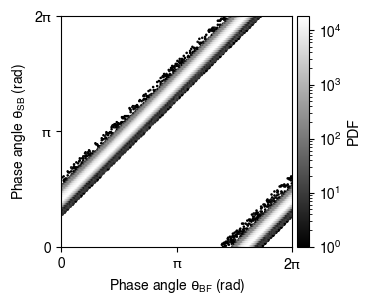

In [5]:
with plot_style():

    fig, ax = plt.subplots(1, 1)
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    cmap = plt.colormaps["binary_r"]

    ax.set_aspect("equal")

    colormesh = ax.hexbin(
        phase_angle_bf["phase_angle"],
        phase_angle_sb["phase_angle"],
        gridsize=200,
        cmap=cmap,
        norm=LogNorm(),
        extent=(0, 2 * np.pi, 0, 2 * np.pi),
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)

    cbar = fig.colorbar(colormesh, ax=ax, label="PDF", pad=0.01, cax=cax)

    ax.set_xlabel(r"Phase angle $\theta_{\text{BF}}$ (rad)")
    ax.set_ylabel(
        r"Phase angle $\theta_{\text{SB}}$ (rad)",
    )

    plt.xticks(rotation=90)

    ticks = [0, np.pi, 2 * np.pi]
    tick_labels = [r"0", r"$\pi$", r"$2\pi$"]
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels)
    ax.set_yticks(ticks)
    ax.set_yticklabels(tick_labels)

    ax.set_xlim(0, 2 * np.pi)
    ax.set_ylim(0, 2 * np.pi)

    plt.show()

# Phase difference distribution

In [6]:
x = phase_angle_sb["phase_angle"] - phase_angle_bf["phase_angle"]

# Translating by 2 pi (physically identical) negative values
mask = np.where(x < 0)
x[mask] = x + 2 * np.pi

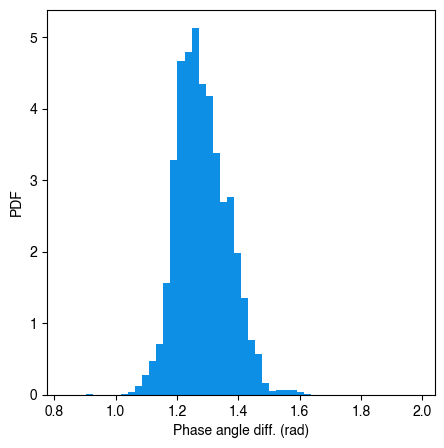

In [7]:
with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax.hist(x, bins=50, density=True)

    ax.set_xlabel("Phase angle diff. (rad)")
    ax.set_ylabel("PDF")

    plt.show()

# Phase difference with "hard-to-spot" outliers

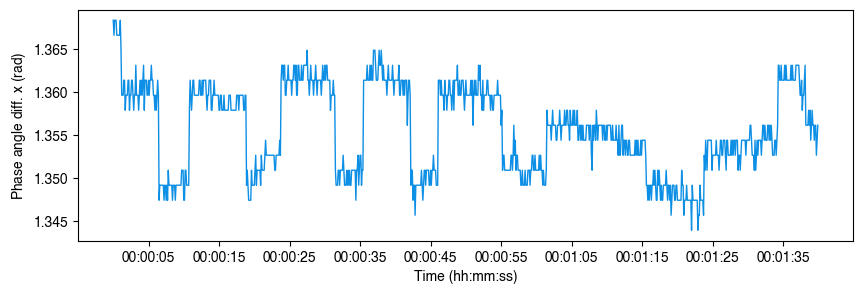

In [8]:
phase_angle_sb["time_stamp"] = pd.to_datetime(phase_angle_sb["time_stamp"])
N = 1000

with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax.plot(
        phase_angle_sb["time_stamp"][:N],
        x[:N],
        lw=1.0,
        color=colors[0],
    )

    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

    ax.set_xlabel("Time (hh:mm:ss)")
    ax.set_ylabel(r"Phase angle diff. $x$ (rad)")

    plt.show()